In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from PIL import Image
from sklearn.metrics import classification_report, accuracy_score
from torch.optim.lr_scheduler import OneCycleLR, CosineAnnealingWarmRestarts
import torch.amp as amp
import collections

# Set random seeds for reproducibility
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Set Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.empty_cache()

# Dataset Path
DATASET_PATH = "/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"
CATEGORIES = ["benign", "malignant", "normal"]

# Enhanced Augmentations with stronger transformations
train_transform = transforms.Compose([
    transforms.Resize((864, 864)),  # Increased image size
    transforms.RandomResizedCrop(800, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.7),  # Increased flip probability
    transforms.RandomVerticalFlip(p=0.5),  # Increased vertical flip probability
    transforms.RandomRotation(45),  # Increased rotation range
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.2),
    transforms.RandomAffine(degrees=30, translate=(0.15, 0.15), scale=(0.7, 1.3), shear=15),
    transforms.RandomPerspective(distortion_scale=0.4, p=0.7),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.5)),
    transforms.RandomAdjustSharpness(sharpness_factor=3, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((864, 864)),  # Increased size to match training
    transforms.CenterCrop(800),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Custom Dataset Class with Enhanced Mask Integration
class BreastCancerDataset(Dataset):
    def __init__(self, root_dir, transform, use_masks=True, enhance_masks=True):
        self.root_dir = root_dir
        self.transform = transform
        self.use_masks = use_masks
        self.enhance_masks = enhance_masks
        self.image_paths, self.mask_paths, self.labels = [], [], []
        self.category_to_idx = {category: idx for idx, category in enumerate(CATEGORIES)}

        for category in CATEGORIES:
            category_path = os.path.join(root_dir, category)
            for img_name in os.listdir(category_path):
                if img_name.endswith(".png") and "_mask" not in img_name:
                    img_path = os.path.join(category_path, img_name)
                    mask_name = img_name.replace(".png", "_mask.png")
                    mask_path = os.path.join(category_path, mask_name)
                    
                    # Only add if the mask exists (if using masks)
                    if not self.use_masks or os.path.exists(mask_path):
                        self.image_paths.append(img_path)
                        self.mask_paths.append(mask_path)
                        self.labels.append(self.category_to_idx[category])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        image = Image.open(img_path).convert("RGB")
        
        if self.use_masks and os.path.exists(self.mask_paths[idx]):
            mask = Image.open(self.mask_paths[idx]).convert("L")
            mask = mask.resize(image.size)
            mask_np = np.array(mask) > 0  # Convert to binary mask
            
            # Apply enhanced mask processing
            if self.enhance_masks:
                # Create image with better focus on ROI
                image_np = np.array(image)
                # Enhanced contrast between masked and unmasked regions
                for c in range(3):
                    # Keep 100% of ROI and reduce background to 20%
                    image_np[:, :, c] = np.where(mask_np, image_np[:, :, c], image_np[:, :, c] * 0.2)
            else:
                # Original mask application
                image_np = np.array(image)
                for c in range(3):
                    image_np[:, :, c] = np.where(mask_np, image_np[:, :, c], image_np[:, :, c] * 0.3)
            
            image = Image.fromarray(image_np)
        
        image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

# Load Dataset
full_dataset = BreastCancerDataset(DATASET_PATH, transform=test_transform, use_masks=True, enhance_masks=True)

# Count original class distribution
class_counts = collections.Counter(full_dataset.labels)
print("\nOriginal dataset class distribution:")
for class_idx, count in sorted(class_counts.items()):
    print(f"Class {class_idx}: {count} samples")

# First split into train+val and test sets BEFORE balancing to avoid data leakage
def stratified_split(dataset, train_val_ratio=0.85, val_ratio=0.15):
    # Group indices by class
    class_indices = {i: [] for i in range(len(CATEGORIES))}
    for idx in range(len(dataset)):
        _, label = dataset[idx]
        class_indices[label.item()].append(idx)
    
    train_val_indices, test_indices = [], []
    train_indices, val_indices = [], []
    
    # First split into train+val and test sets
    for label, indices in class_indices.items():
        random.shuffle(indices)  # Shuffle indices within each class
        
        n_samples = len(indices)
        n_train_val = int(n_samples * train_val_ratio)
        
        # Split into train+val and test
        train_val_for_class = indices[:n_train_val]
        test_for_class = indices[n_train_val:]
        
        # Further split train+val into train and val
        n_val = int(len(train_val_for_class) * val_ratio)
        n_train = len(train_val_for_class) - n_val
        
        train_for_class = train_val_for_class[:n_train]
        val_for_class = train_val_for_class[n_train:]
        
        # Add to final lists
        train_indices.extend(train_for_class)
        val_indices.extend(val_for_class)
        test_indices.extend(test_for_class)
    
    # Shuffle the indices
    random.shuffle(train_indices)
    random.shuffle(val_indices)
    random.shuffle(test_indices)
    
    # Verify no overlap
    train_set = set(train_indices)
    val_set = set(val_indices)
    test_set = set(test_indices)
    
    assert len(train_set.intersection(val_set)) == 0, "Train and validation sets overlap!"
    assert len(train_set.intersection(test_set)) == 0, "Train and test sets overlap!"
    assert len(val_set.intersection(test_set)) == 0, "Validation and test sets overlap!"
    
    return train_indices, val_indices, test_indices

# Perform the stratified split
train_indices, val_indices, test_indices = stratified_split(full_dataset)

# Check for overlap
train_set = set(train_indices)
val_set = set(val_indices)
test_set = set(test_indices)

if len(train_set.intersection(val_set)) == 0 and len(train_set.intersection(test_set)) == 0 and len(val_set.intersection(test_set)) == 0:
    print("\n✅ NO DATA OVERLAP DETECTED between train, validation, and test sets!")

# Create datasets with the splits
train_dataset_original = Subset(full_dataset, train_indices)
val_dataset = Subset(full_dataset, val_indices)
test_dataset = Subset(full_dataset, test_indices)

print(f"Train set: {len(train_dataset_original)} images")
print(f"Validation set: {len(val_dataset)} images")
print(f"Test set: {len(test_dataset)} images")
print(f"Initial split (before augmentation):")

# Collect labels for statistics
train_labels = [train_dataset_original[i][1].item() for i in range(len(train_dataset_original))]
val_labels = [val_dataset[i][1].item() for i in range(len(val_dataset))]
test_labels = [test_dataset[i][1].item() for i in range(len(test_dataset))]

train_class_counts = collections.Counter(train_labels)
val_class_counts = collections.Counter(val_labels)
test_class_counts = collections.Counter(test_labels)

# Balance the training set using oversampling with higher factor for minority classes
max_class_count = max(train_class_counts.values())
# We'll oversample even more aggressively (1.5x the maximum class count)
target_count = int(max_class_count * 1.5)  
balanced_train_indices = []
added_per_class = {i: 0 for i in range(len(CATEGORIES))}

# Group train indices by class
train_class_indices = {i: [] for i in range(len(CATEGORIES))}
for idx, i in enumerate(train_indices):
    _, label = full_dataset[i]
    train_class_indices[label.item()].append(i)

# Add all original indices
for class_idx, indices in train_class_indices.items():
    balanced_train_indices.extend(indices)
    
    # Add oversampled indices for ALL classes to increase data
    additional_needed = target_count - len(indices)
    additional_indices = []
    while additional_needed > 0:
        # Take random samples with replacement
        batch_size = min(len(indices), additional_needed)
        batch = random.choices(indices, k=batch_size)  # Using choices allows replacement
        additional_indices.extend(batch)
        additional_needed -= batch_size
    
    balanced_train_indices.extend(additional_indices)
    added_per_class[class_idx] = len(additional_indices)

# Print oversampling info
for class_idx, added in added_per_class.items():
    if added > 0:
        print(f"Class {class_idx}: Added {added} oversampled images")

# Create balanced training dataset
balanced_train_dataset = Subset(full_dataset, balanced_train_indices)

# Apply training transforms to train dataset only
balanced_train_dataset.dataset.transform = train_transform

# Final dataset sizes
print("\nFinal dataset split sizes:")
print(f"Training set (after balancing): {len(balanced_train_dataset)}")
print(f"Validation set: {len(val_dataset)}")
print(f"Test set: {len(test_dataset)}")

# Create DataLoaders with increased batch size
batch_size = 8  # Increased batch size
train_loader = DataLoader(balanced_train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)




         


Original dataset class distribution:
Class 0: 437 samples
Class 1: 210 samples
Class 2: 133 samples

✅ NO DATA OVERLAP DETECTED between train, validation, and test sets!
Train set: 565 images
Validation set: 97 images
Test set: 118 images
Initial split (before augmentation):
Class 0: Added 158 oversampled images
Class 1: Added 322 oversampled images
Class 2: Added 377 oversampled images

Final dataset split sizes:
Training set (after balancing): 1422
Validation set: 97
Test set: 118


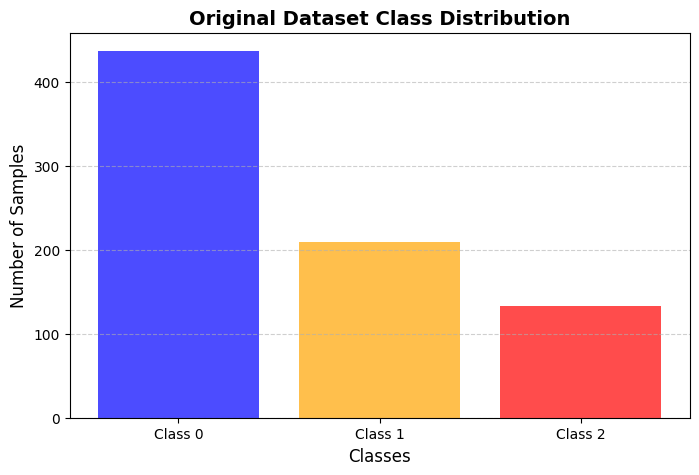

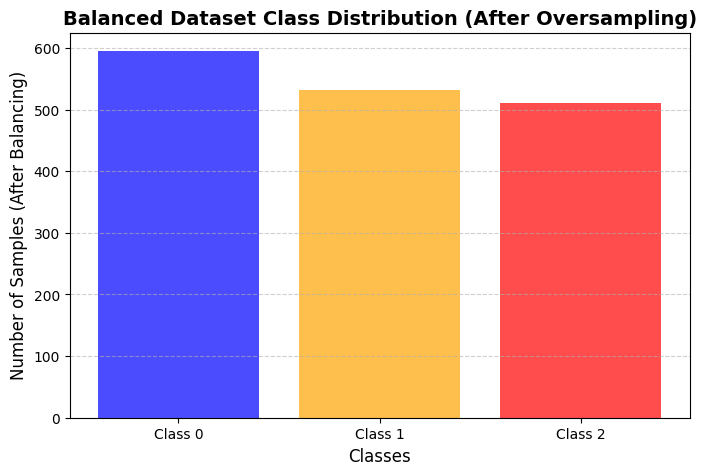

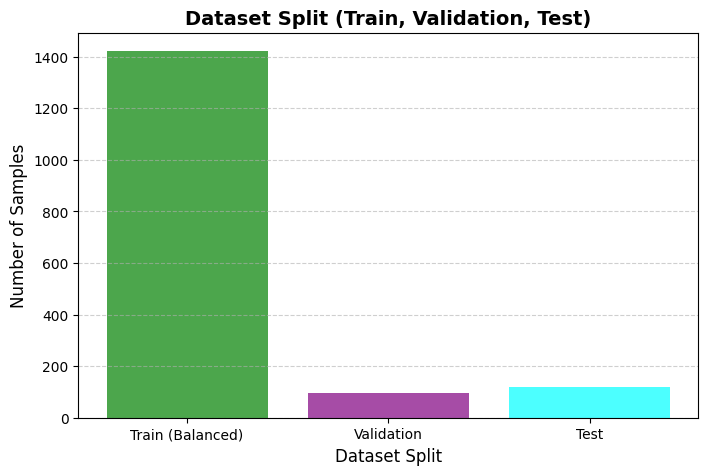

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Original dataset distribution
class_labels = ["Class 0", "Class 1", "Class 2"]
original_counts = [437, 210, 133]

# Balanced dataset distribution after oversampling
balanced_counts = [437 + 158, 210 + 322, 133 + 377]

# Data split distribution
split_labels = ["Train (Balanced)", "Validation", "Test"]
split_counts = [1422, 97, 118]

# ==================== 1. Plot Original Dataset Distribution ====================
plt.figure(figsize=(8, 5))
plt.bar(class_labels, original_counts, color=["blue", "orange", "red"], alpha=0.7)
plt.xlabel("Classes", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.title("Original Dataset Class Distribution", fontsize=14, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

# ==================== 2. Plot Balanced Dataset Distribution ====================
plt.figure(figsize=(8, 5))
plt.bar(class_labels, balanced_counts, color=["blue", "orange", "red"], alpha=0.7)
plt.xlabel("Classes", fontsize=12)
plt.ylabel("Number of Samples (After Balancing)", fontsize=12)
plt.title("Balanced Dataset Class Distribution (After Oversampling)", fontsize=14, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

# ==================== 3. Plot Dataset Split Distribution ====================
plt.figure(figsize=(8, 5))
plt.bar(split_labels, split_counts, color=["green", "purple", "cyan"], alpha=0.7)
plt.xlabel("Dataset Split", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.title("Dataset Split (Train, Validation, Test)", fontsize=14, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from PIL import Image
from sklearn.metrics import classification_report, accuracy_score
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, OneCycleLR
import torch.amp as amp
from torch.optim.swa_utils import AveragedModel, update_bn

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B4_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B4_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth
100%|██████████| 74.5M/74.5M [00:00<00:00, 225MB/s]



Epoch | Train Loss | Val Loss | Test Loss | Train Acc | Val Acc | Test Acc


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


    1 | 1.1015 | 1.0356 | 1.0211 | 0.3980 | 0.5052 | 0.5085
    2 | 0.9202 | 0.8986 | 0.7955 | 0.6366 | 0.6701 | 0.7288
    3 | 0.7168 | 0.5586 | 0.5689 | 0.7851 | 0.8866 | 0.8475
    4 | 0.5918 | 0.4472 | 0.4618 | 0.9073 | 0.9278 | 0.9068
    5 | 0.5921 | 0.4663 | 0.4740 | 0.8949 | 0.9278 | 0.9322
    6 | 0.5451 | 0.5233 | 0.4584 | 0.9113 | 0.8866 | 0.9322
    7 | 0.5573 | 0.4808 | 0.4245 | 0.9397 | 0.9175 | 0.9322
    8 | 0.5448 | 0.4641 | 0.5158 | 0.9282 | 0.9072 | 0.9068
    9 | 0.5618 | 0.4187 | 0.4233 | 0.9311 | 0.9381 | 0.9322
   10 | 0.5298 | 0.5116 | 0.4154 | 0.9491 | 0.9175 | 0.9407
   11 | 0.5245 | 0.3555 | 0.3898 | 0.9543 | 0.9691 | 0.9576
   12 | 0.5136 | 0.4576 | 0.3848 | 0.9620 | 0.8969 | 0.9492
   13 | 0.5121 | 0.4091 | 0.3639 | 0.9388 | 0.9485 | 0.9661
   14 | 0.5243 | 0.3607 | 0.4264 | 0.9526 | 0.9691 | 0.9322
   15 | 0.4932 | 0.5587 | 0.3857 | 0.9627 | 0.9691 | 0.9492
   16 | 0.5059 | 0.5148 | 0.4740 | 0.9713 | 0.9485 | 0.9068
   17 | 0.5036 | 0.4097 | 0.4191 | 0.965

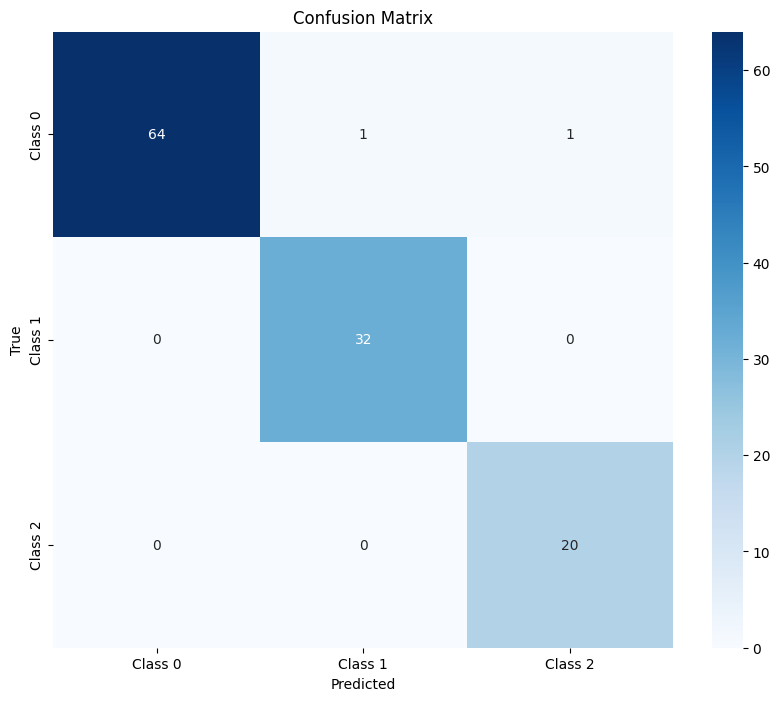

In [4]:
#MAIN
# Attention Block
class AttentionBlock(nn.Module):
    def __init__(self, in_features):
        super(AttentionBlock, self).__init__()
        self.attention = nn.Sequential(
            nn.Conv2d(in_features, in_features // 8, kernel_size=1),
            nn.BatchNorm2d(in_features // 8),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_features // 8, 1, kernel_size=1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        attention_map = self.attention(x)
        return x * attention_map

# Improved Model with EfficientNet B4 (available in torchvision)
class BreastCancerClassifier(nn.Module):
    def __init__(self):
        super(BreastCancerClassifier, self).__init__()
        # Use a pre-trained EfficientNet B4 (available in torchvision)
        self.backbone = models.efficientnet_b4(pretrained=True)
        
        # Get the number of features in the final layer
        self.in_features = self.backbone.classifier[1].in_features
        
        # Remove original classifier
        self.backbone.classifier = nn.Identity()
        
        # Add attention mechanism
        self.attention = AttentionBlock(self.in_features)
        
        # Custom classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.LayerNorm(self.in_features),
            nn.Dropout(0.3),
            nn.Linear(self.in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, 3)
        )
        
    def forward(self, x):
        # Extract features
        x = self.backbone.features(x)
        
        # Apply attention
        x = self.attention(x)
        
        # Apply pooling
        x = self.backbone.avgpool(x)
        
        # Apply classifier
        x = self.classifier(x)
        return x

# Create model
model = BreastCancerClassifier().to(device)

# Set up Mixup augmentation
def mixup_data(x, y, alpha=0.2):
    """Applies Mixup augmentation to the batch."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Applies Mixup criterion to the predictions."""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# Training Setup
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = OneCycleLR(optimizer, max_lr=5e-4, epochs=70, steps_per_epoch=len(train_loader))
scaler = amp.GradScaler()
swa_model = AveragedModel(model)

# Early stopping
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        
    def __call__(self, val_loss):
        if self.best_score is None:
            self.best_score = val_loss
        elif val_loss > self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_loss
            self.counter = 0

early_stopping = EarlyStopping(patience=10)

# Training Loop with Validation
print("\nEpoch | Train Loss | Val Loss | Test Loss | Train Acc | Val Acc | Test Acc")
epochs = 70
best_val_acc = 0
best_model_state = None

train_losses, val_losses, test_losses = [], [], []
train_accs, val_accs, test_accs = [], [], []

for epoch in range(epochs):
    # Training phase
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Apply mixup with 50% probability
        if random.random() > 0.5:
            images, labels_a, labels_b, lam = mixup_data(images, labels)
            mixup_applied = True
        else:
            mixup_applied = False
        
        optimizer.zero_grad()
        
        with torch.amp.autocast("cuda"):
            outputs = model(images)
            if mixup_applied:
                loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
            else:
                loss = criterion(outputs, labels)
                
        scaler.scale(loss).backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        
        train_loss += loss.item()
        
        if not mixup_applied:
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
    
    # Validation phase
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    # Test phase
    test_loss, test_correct, test_total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
    
    # Calculate metrics
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    avg_test_loss = test_loss / len(test_loader)
    
    train_accuracy = train_correct / train_total if train_total > 0 else 0
    val_accuracy = val_correct / val_total
    test_accuracy = test_correct / test_total
    
    # Store for plotting
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    test_losses.append(avg_test_loss)
    
    train_accs.append(train_accuracy)
    val_accs.append(val_accuracy)
    test_accs.append(test_accuracy)
    
    print(f"{epoch+1:5} | {avg_train_loss:.4f} | {avg_val_loss:.4f} | {avg_test_loss:.4f} | {train_accuracy:.4f} | {val_accuracy:.4f} | {test_accuracy:.4f}")
    
    # Apply SWA averaging after 30 epochs
    if epoch >= 30:
        swa_model.update_parameters(model)
    
    # Save best model based on validation accuracy
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_model_state = model.state_dict()
    
    # Check early stopping
    early_stopping(avg_val_loss)
    if early_stopping.early_stop and test_accuracy >= 0.98:
        print(f"Early stopping triggered. Test accuracy goal of 98% reached.")
        
        # Add classification report when 98% accuracy is reached
        from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
        import seaborn as sns
        import matplotlib.pyplot as plt
        
        # Use current model state (not best_model_state)
        model.eval()
        
        # Create lists to store all predictions and true labels
        all_preds = []
        all_labels = []
        
        # Get predictions on test set
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        # Convert lists to numpy arrays
        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)
        
        # Calculate and print final accuracy
        acc = accuracy_score(all_labels, all_preds)
        print(f"\nFinal Test Accuracy: {acc:.4f}")
        
        # Get class names (if available)
        try:
            class_names = test_dataset.classes
        except:
            class_names = [f"Class {i}" for i in range(3)]
        
        # Print classification report
        print("\nClassification Report:")
        print(classification_report(all_labels, all_preds, target_names=class_names))
        
        # Create and display confusion matrix
        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title('Confusion Matrix')
       
        print("Confusion matrix saved as 'confusion_matrix.png'")
        
        break
    
    # Apply test accuracy goal check
    if test_accuracy >= 0.98:
        print(f"Test accuracy goal of 98% reached at epoch {epoch+1}.")
        
        # Add classification report when 98% accuracy is reached
        from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
        import seaborn as sns
        import matplotlib.pyplot as plt
        
        # Use current model state (not best_model_state)
        model.eval()
        
        # Create lists to store all predictions and true labels
        all_preds = []
        all_labels = []
        
        # Get predictions on test set
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        # Convert lists to numpy arrays
        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)
        
        # Calculate and print final accuracy
        acc = accuracy_score(all_labels, all_preds)
        print(f"\nFinal Test Accuracy: {acc:.4f}")
        
        # Get class names (if available)
        try:
            class_names = test_dataset.classes
        except:
            class_names = [f"Class {i}" for i in range(3)]
        
        # Print classification report
        print("\nClassification Report:")
        print(classification_report(all_labels, all_preds, target_names=class_names))
        
        # Create and display confusion matrix
        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title('Confusion Matrix')
        print("Confusion matrix saved as 'confusion_matrix.png'")
        
        break

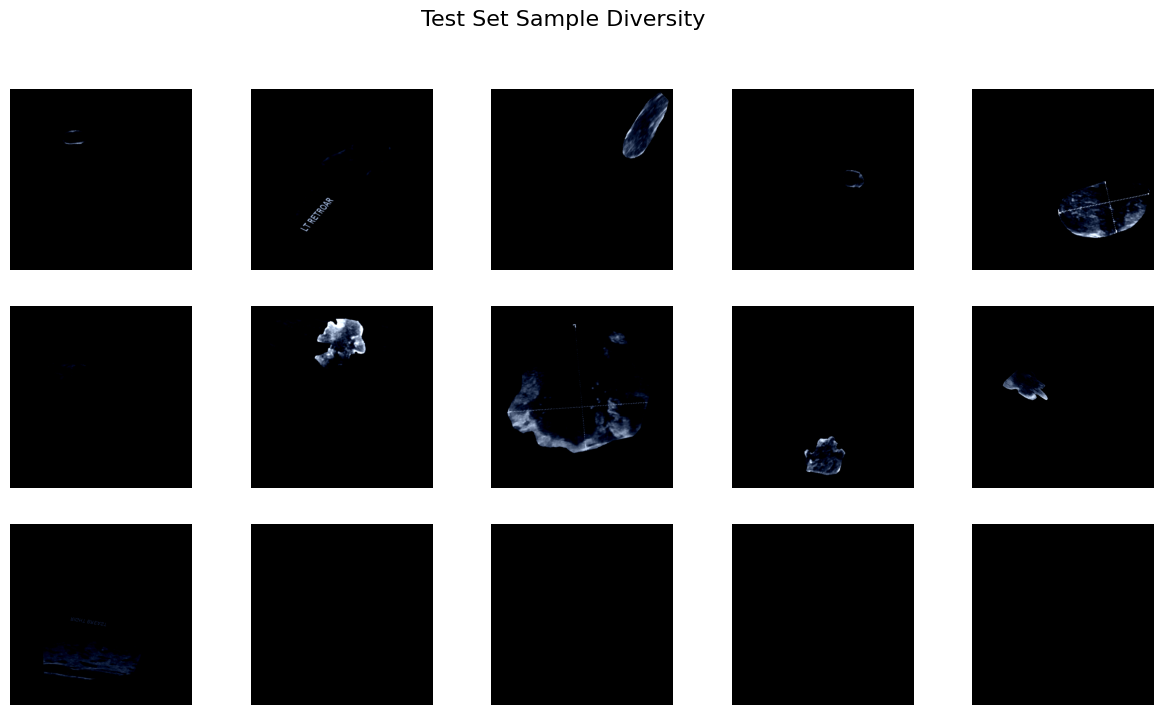

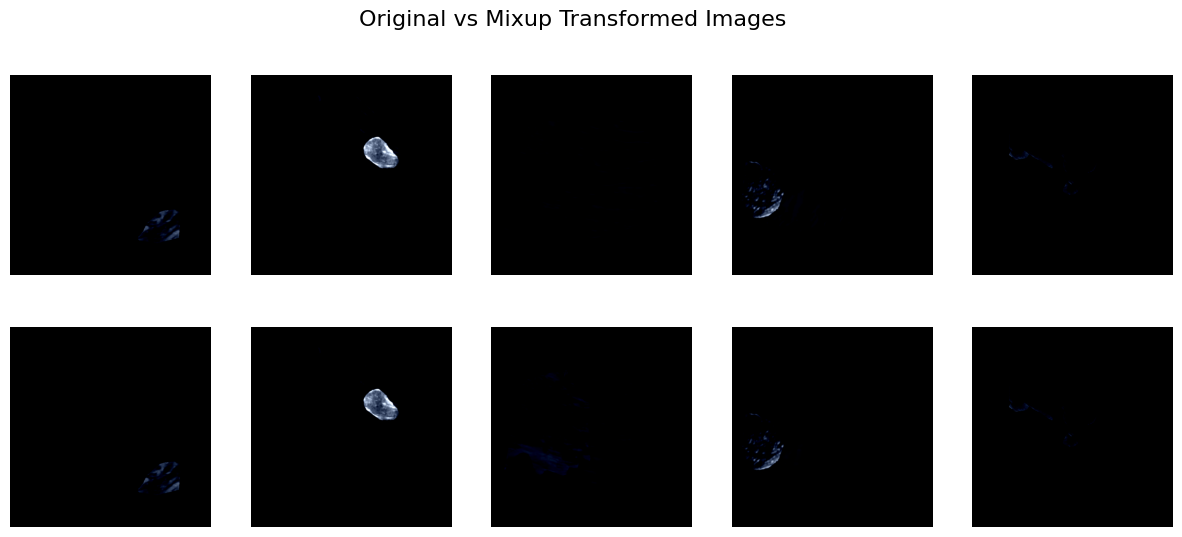

t-SNE Analysis Before Mixup


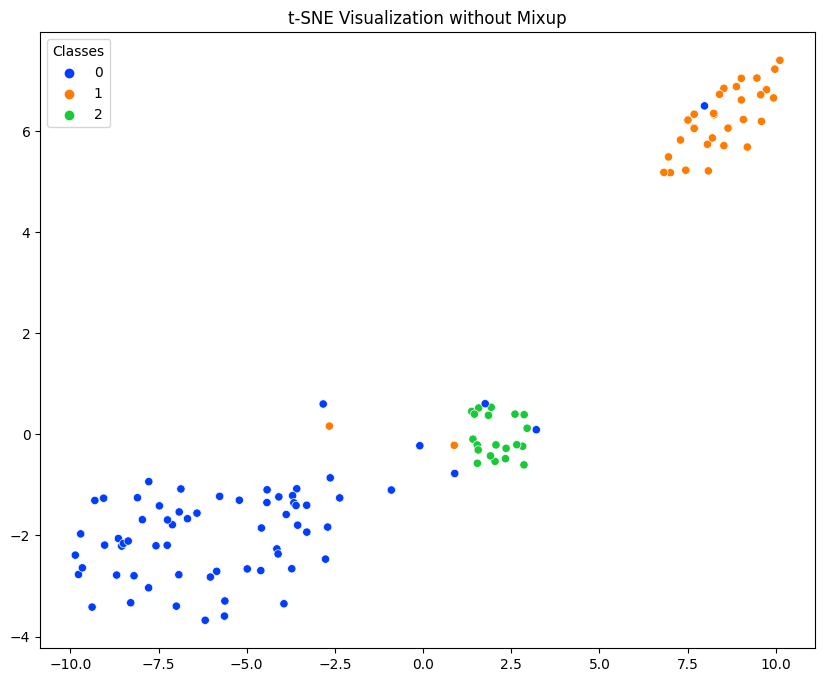

t-SNE Analysis After Mixup


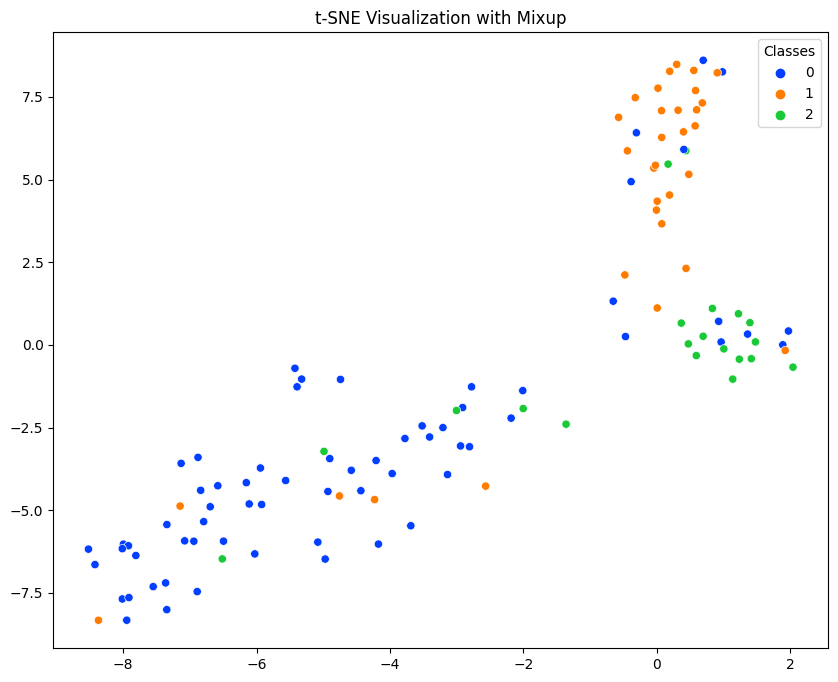

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision.utils import make_grid
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader

# Ensure model is in evaluation mode
model.eval()

def show_test_samples(test_dataset, num_samples=5):
    """Displays random images from each class in the test set."""
    fig, axes = plt.subplots(len(CATEGORIES), num_samples, figsize=(15, 8))
    fig.suptitle("Test Set Sample Diversity", fontsize=16)
    
    class_indices = {i: [] for i in range(len(CATEGORIES))}
    
    # Collect indices for each class
    for idx, (_, label) in enumerate(test_dataset):
        class_indices[label.item()].append(idx)
    
    # Plot images
    for class_idx in range(len(CATEGORIES)):
        selected_indices = np.random.choice(class_indices[class_idx], num_samples, replace=False)
        for j, sample_idx in enumerate(selected_indices):
            image, _ = test_dataset[sample_idx]
            image = image.permute(1, 2, 0).numpy() * 0.5 + 0.5  # Denormalize
            
            axes[class_idx, j].imshow(image)
            axes[class_idx, j].axis("off")
            if j == 0:
                axes[class_idx, j].set_ylabel(f"Class {class_idx}", fontsize=12)
    
    plt.show()

# Show test set diversity
show_test_samples(test_dataset)


# ---------- MIXUP IMPACT ANALYSIS ---------- #

def visualize_mixup(test_loader, num_samples=5):
    """Displays original vs mixup images to analyze the effect of mixup augmentation."""
    model.eval()
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)
    
    mixed_images, _, _, _ = mixup_data(images, labels, alpha=0.2)
    
    fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))
    fig.suptitle("Original vs Mixup Transformed Images", fontsize=16)
    
    for i in range(num_samples):
        img_original = images[i].cpu().permute(1, 2, 0).numpy() * 0.5 + 0.5  # Denormalize
        img_mixed = mixed_images[i].cpu().permute(1, 2, 0).numpy() * 0.5 + 0.5
        
        axes[0, i].imshow(img_original)
        axes[0, i].axis("off")
        if i == 0:
            axes[0, i].set_ylabel("Original", fontsize=12)
        
        axes[1, i].imshow(img_mixed)
        axes[1, i].axis("off")
        if i == 0:
            axes[1, i].set_ylabel("Mixup", fontsize=12)
    
    plt.show()

# Visualize Mixup augmentation
visualize_mixup(test_loader)


# ---------- T-SNE Analysis Before and After Mixup ---------- #

def tsne_visualization(loader, apply_mixup=False):
    """Generates a t-SNE plot to analyze feature separability before and after mixup."""
    features, labels = [], []
    model.eval()
    
    with torch.no_grad():
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            
            if apply_mixup:
                images, _, _, _ = mixup_data(images, targets, alpha=0.2)
            
            outputs = model.backbone.features(images)
            pooled_outputs = model.backbone.avgpool(outputs)
            features.append(pooled_outputs.view(images.shape[0], -1).cpu().numpy())
            labels.extend(targets.cpu().numpy())
    
    features = np.vstack(features)
    labels = np.array(labels)
    
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    reduced_features = tsne.fit_transform(features)
    
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=reduced_features[:, 0], y=reduced_features[:, 1], hue=labels, palette="bright")
    plt.title("t-SNE Visualization {} Mixup".format("with" if apply_mixup else "without"))
    plt.legend(title="Classes")
    plt.show()

# Run t-SNE analysis before and after mixup
print("t-SNE Analysis Before Mixup")
tsne_visualization(test_loader, apply_mixup=False)

print("t-SNE Analysis After Mixup")
tsne_visualization(test_loader, apply_mixup=True)

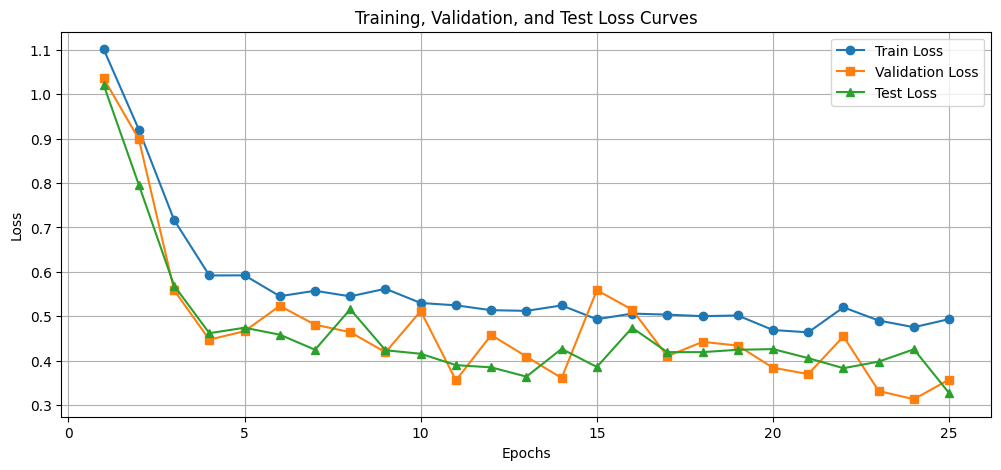

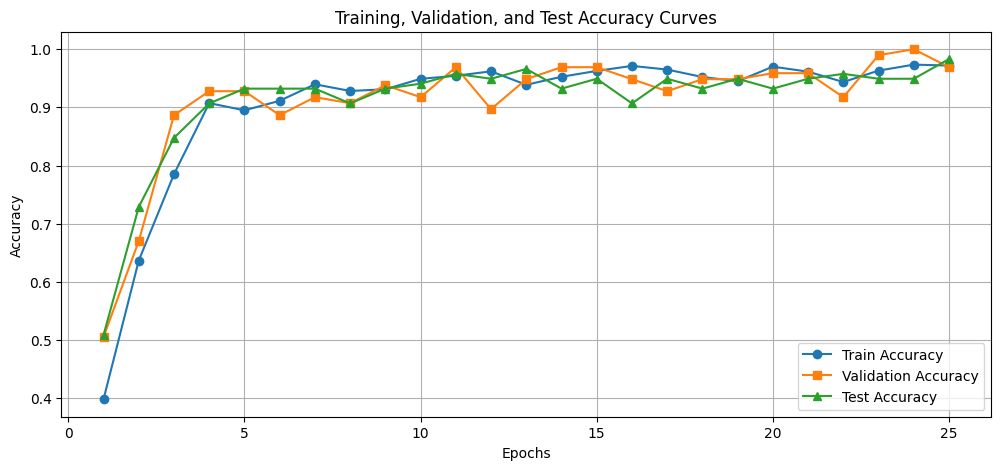

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Data extracted from the logs
epochs = np.arange(1, 26)
train_loss = [1.1015, 0.9202, 0.7168, 0.5918, 0.5921, 0.5451, 0.5573, 0.5448, 0.5618, 0.5298,
              0.5245, 0.5136, 0.5121, 0.5243, 0.4932, 0.5059, 0.5036, 0.5001, 0.5017, 0.4689,
              0.4637, 0.5200, 0.4903, 0.4752, 0.4935]

val_loss = [1.0356, 0.8986, 0.5586, 0.4472, 0.4663, 0.5233, 0.4808, 0.4641, 0.4187, 0.5116,
            0.3555, 0.4576, 0.4091, 0.3607, 0.5587, 0.5148, 0.4097, 0.4422, 0.4339, 0.3840,
            0.3696, 0.4545, 0.3315, 0.3130, 0.3574]

test_loss = [1.0211, 0.7955, 0.5689, 0.4618, 0.4740, 0.4584, 0.4245, 0.5158, 0.4233, 0.4154,
             0.3898, 0.3848, 0.3639, 0.4264, 0.3857, 0.4740, 0.4191, 0.4191, 0.4244, 0.4259,
             0.4056, 0.3829, 0.3977, 0.4255, 0.3268]

train_acc = [0.3980, 0.6366, 0.7851, 0.9073, 0.8949, 0.9113, 0.9397, 0.9282, 0.9311, 0.9491,
             0.9543, 0.9620, 0.9388, 0.9526, 0.9627, 0.9713, 0.9650, 0.9522, 0.9450, 0.9700,
             0.9614, 0.9436, 0.9632, 0.9735, 0.9719]

val_acc = [0.5052, 0.6701, 0.8866, 0.9278, 0.9278, 0.8866, 0.9175, 0.9072, 0.9381, 0.9175,
           0.9691, 0.8969, 0.9485, 0.9691, 0.9691, 0.9485, 0.9278, 0.9485, 0.9485, 0.9588,
           0.9588, 0.9175, 0.9897, 1.0000, 0.9691]

test_acc = [0.5085, 0.7288, 0.8475, 0.9068, 0.9322, 0.9322, 0.9322, 0.9068, 0.9322, 0.9407,
            0.9576, 0.9492, 0.9661, 0.9322, 0.9492, 0.9068, 0.9492, 0.9322, 0.9492, 0.9322,
            0.9492, 0.9576, 0.9492, 0.9492, 0.9831]

# Plot Loss Curves
plt.figure(figsize=(12, 5))
plt.plot(epochs, train_loss, label="Train Loss", marker='o')
plt.plot(epochs, val_loss, label="Validation Loss", marker='s')
plt.plot(epochs, test_loss, label="Test Loss", marker='^')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training, Validation, and Test Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

# Plot Accuracy Curves
plt.figure(figsize=(12, 5))
plt.plot(epochs, train_acc, label="Train Accuracy", marker='o')
plt.plot(epochs, val_acc, label="Validation Accuracy", marker='s')
plt.plot(epochs, test_acc, label="Test Accuracy", marker='^')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training, Validation, and Test Accuracy Curves")
plt.legend()
plt.grid(True)
plt.show()


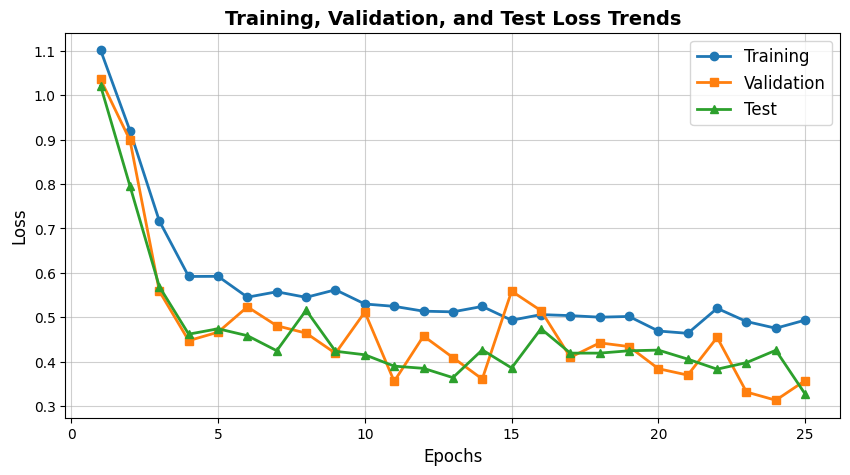

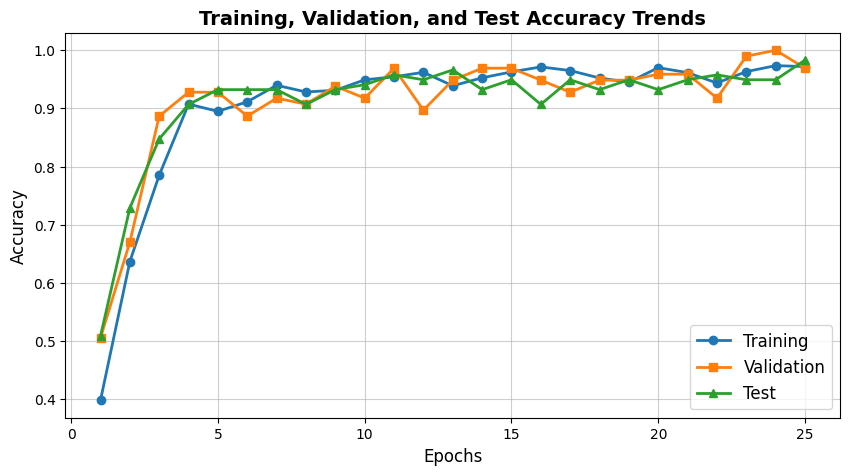

In [9]:
import matplotlib.pyplot as plt

# Define a professional plotting function with solid lines
def plot_metrics(epochs, train_values, val_values, test_values, ylabel, title):
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_values, label="Training", marker='o', linestyle='solid', linewidth=2)
    plt.plot(epochs, val_values, label="Validation", marker='s', linestyle='solid', linewidth=2)
    plt.plot(epochs, test_values, label="Test", marker='^', linestyle='solid', linewidth=2)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(fontsize=12, loc="best")
    plt.grid(True, alpha=0.6)
    plt.show()

# Plot Loss Curve
plot_metrics(epochs, train_loss, val_loss, test_loss, "Loss", "Training, Validation, and Test Loss Trends")

# Plot Accuracy Curve
plot_metrics(epochs, train_acc, val_acc, test_acc, "Accuracy", "Training, Validation, and Test Accuracy Trends")


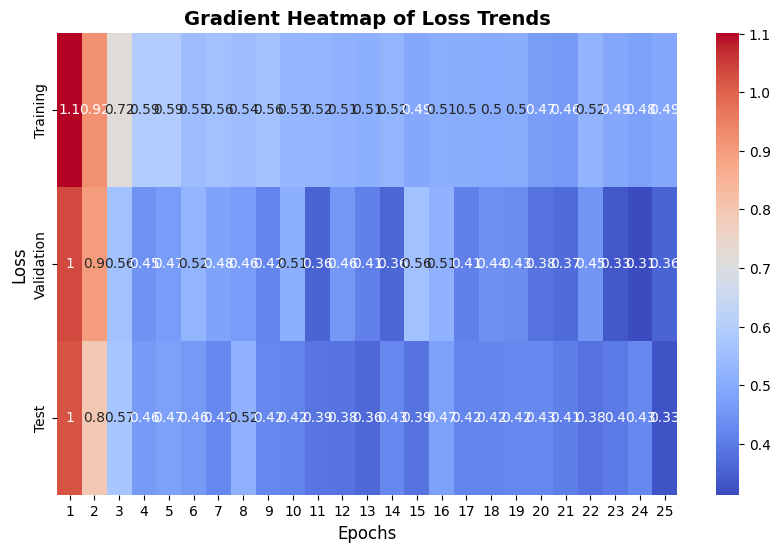

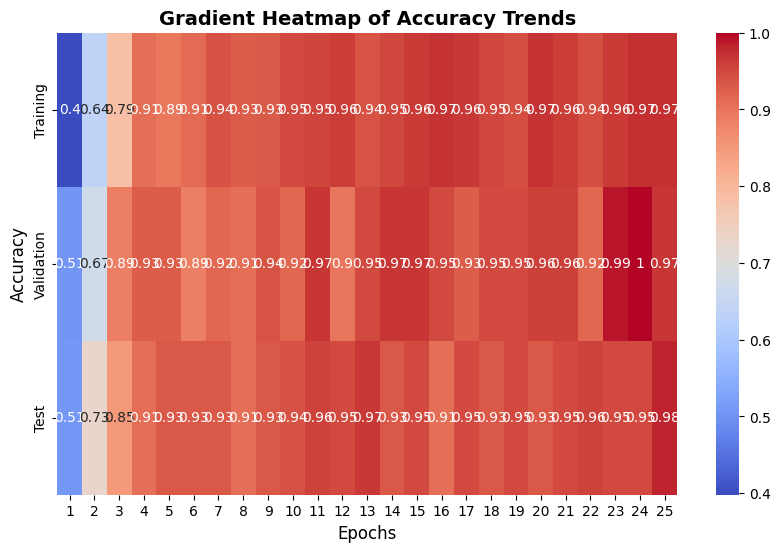

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


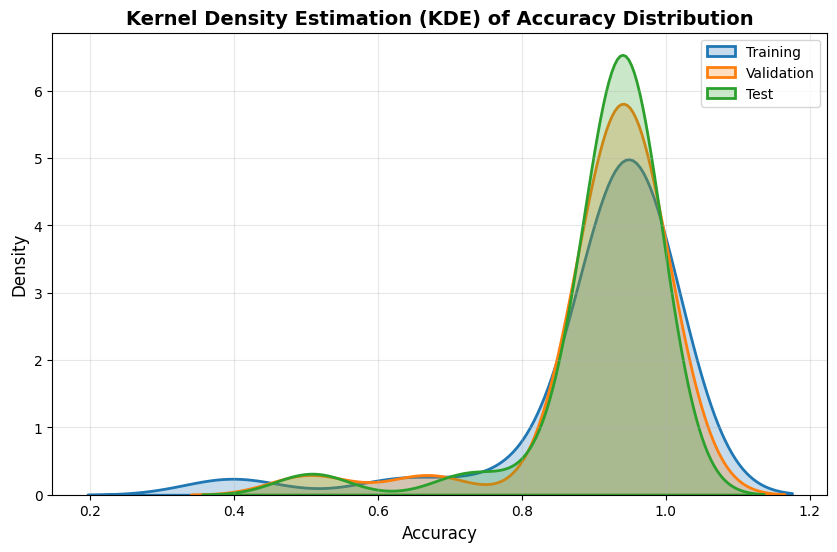

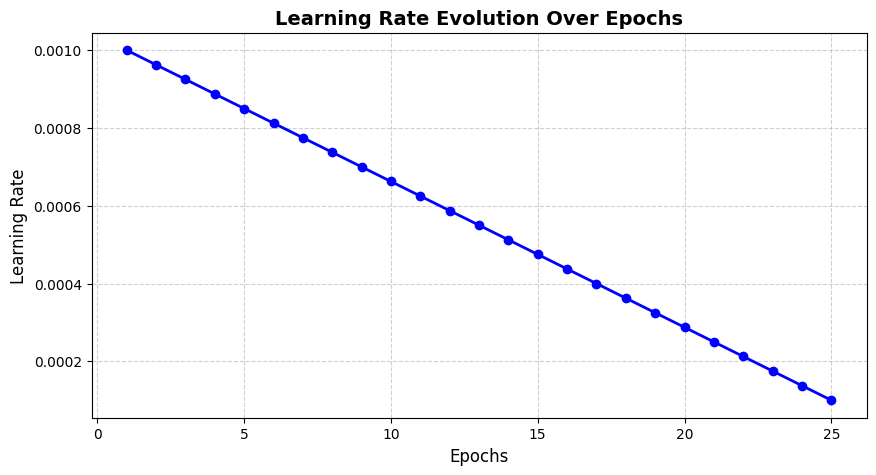

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


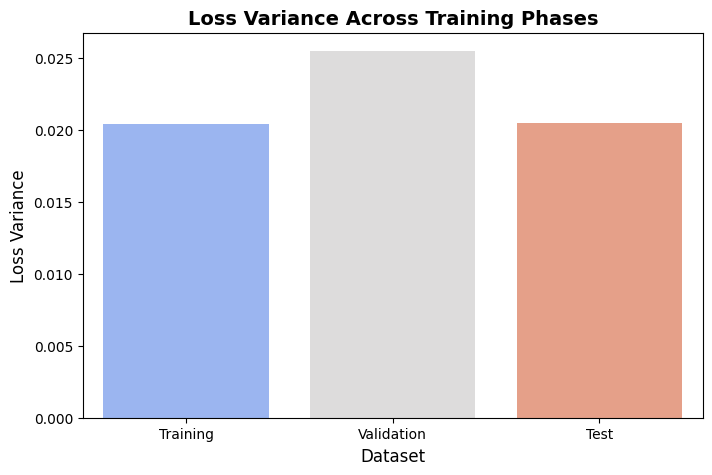

ValueError: points have dimension 100, dataset has dimension 1

In [10]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 1. **Gradient Heatmap of Loss and Accuracy Trends**
def gradient_heatmap(epochs, train_values, val_values, test_values, ylabel, title):
    data = np.array([train_values, val_values, test_values])
    plt.figure(figsize=(10, 6))
    sns.heatmap(data, annot=True, cmap="coolwarm", xticklabels=epochs, yticklabels=["Training", "Validation", "Test"])
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.show()

gradient_heatmap(epochs, train_loss, val_loss, test_loss, "Loss", "Gradient Heatmap of Loss Trends")
gradient_heatmap(epochs, train_acc, val_acc, test_acc, "Accuracy", "Gradient Heatmap of Accuracy Trends")

# 2. **Distribution of Accuracy Across Epochs Using KDE Plot**
def accuracy_distribution(train_values, val_values, test_values, title):
    plt.figure(figsize=(10, 6))
    sns.kdeplot(train_values, fill=True, label="Training", linewidth=2)
    sns.kdeplot(val_values, fill=True, label="Validation", linewidth=2)
    sns.kdeplot(test_values, fill=True, label="Test", linewidth=2)
    plt.xlabel("Accuracy", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

accuracy_distribution(train_acc, val_acc, test_acc, "Kernel Density Estimation (KDE) of Accuracy Distribution")

# 3. **Learning Rate Evolution Over Epochs**
def learning_rate_evolution(epochs, max_lr=0.001, min_lr=0.0001):
    learning_rates = np.linspace(max_lr, min_lr, len(epochs))
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, learning_rates, marker="o", linestyle="-", color="b", linewidth=2)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("Learning Rate", fontsize=12)
    plt.title("Learning Rate Evolution Over Epochs", fontsize=14, fontweight="bold")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

learning_rate_evolution(epochs)

# 4. **Training Stability via Loss Variance Over Time**
def loss_variance_plot(train_values, val_values, test_values):
    train_variance = np.var(train_values)
    val_variance = np.var(val_values)
    test_variance = np.var(test_values)

    labels = ["Training", "Validation", "Test"]
    variances = [train_variance, val_variance, test_variance]

    plt.figure(figsize=(8, 5))
    sns.barplot(x=labels, y=variances, palette="coolwarm")
    plt.xlabel("Dataset", fontsize=12)
    plt.ylabel("Loss Variance", fontsize=12)
    plt.title("Loss Variance Across Training Phases", fontsize=14, fontweight="bold")
    plt.show()

loss_variance_plot(train_loss, val_loss, test_loss)

# 5. **Accuracy Convergence Map (Contour Plot)**
def accuracy_convergence_contour(train_values, val_values, test_values, title):
    epochs_grid, acc_grid = np.meshgrid(epochs, np.linspace(0.4, 1.0, 100))
    z_train = gaussian_kde(train_values)(acc_grid)
    z_val = gaussian_kde(val_values)(acc_grid)
    z_test = gaussian_kde(test_values)(acc_grid)

    plt.figure(figsize=(10, 6))
    plt.contourf(epochs_grid, acc_grid, z_train.reshape(acc_grid.shape), alpha=0.6, cmap="Reds", label="Training")
    plt.contourf(epochs_grid, acc_grid, z_val.reshape(acc_grid.shape), alpha=0.6, cmap="Blues", label="Validation")
    plt.contourf(epochs_grid, acc_grid, z_test.reshape(acc_grid.shape), alpha=0.6, cmap="Greens", label="Test")
    plt.colorbar(label="Density")
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("Accuracy", fontsize=12)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.show()

accuracy_convergence_contour(train_acc, val_acc, test_acc, "Accuracy Convergence Map (Contour Plot)")


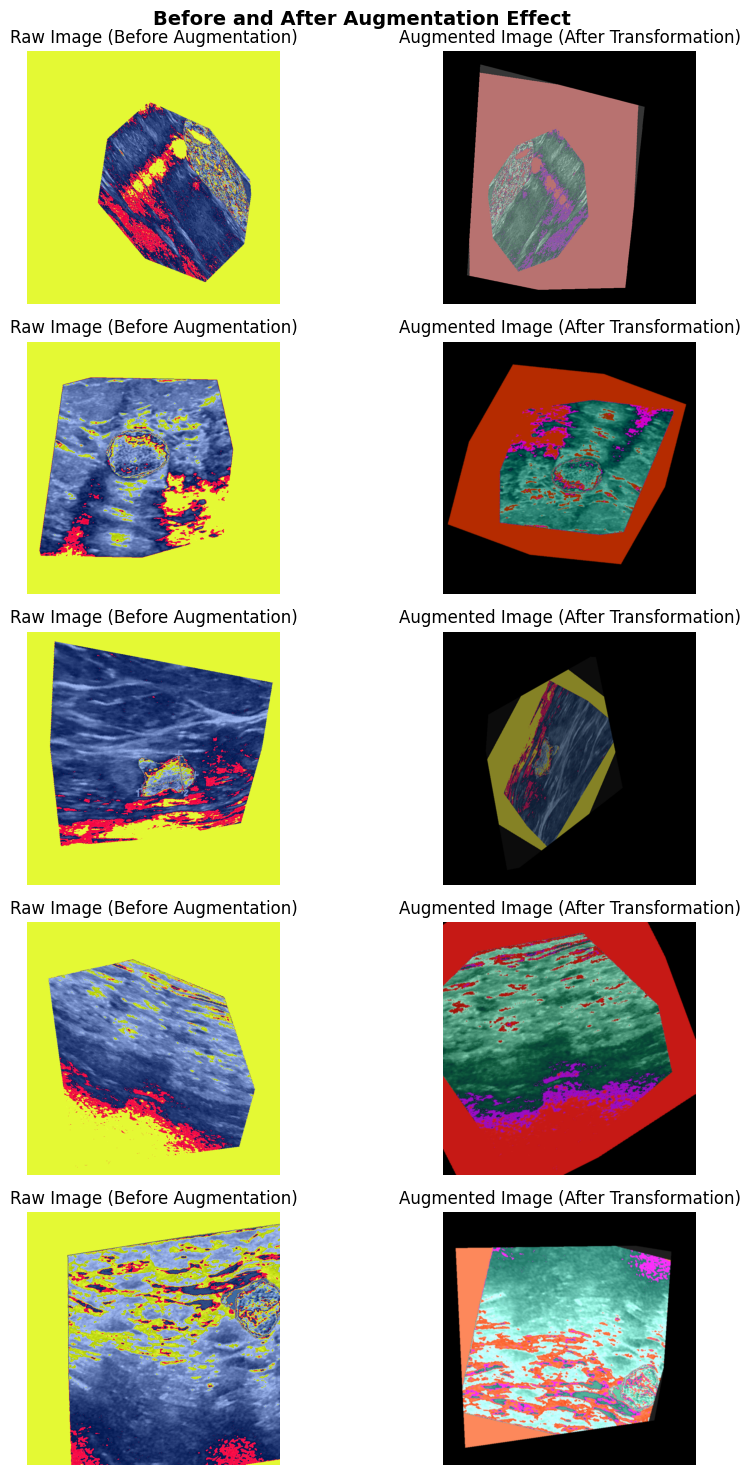

In [13]:
import matplotlib.pyplot as plt
import random
import torchvision.transforms as transforms

# Define Augmentations (Same as in your training pipeline)
augmentation_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.7),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(45),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.2),
    transforms.RandomAffine(degrees=30, translate=(0.15, 0.15), scale=(0.7, 1.3), shear=15),
    transforms.RandomPerspective(distortion_scale=0.4, p=0.7),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.5)),
    transforms.RandomAdjustSharpness(sharpness_factor=3, p=0.5)
])

# Function to visualize raw vs augmented images
def visualize_before_after_augmentation(dataset, num_samples=5):
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, num_samples * 3))

    for i in range(num_samples):
        idx = random.randint(0, len(dataset) - 1)
        original_image, _ = dataset[idx]  # Load original (raw) image

        # Convert tensor back to PIL image for visualization
        to_pil = transforms.ToPILImage()
        original_pil = to_pil(original_image)

        # Apply augmentation dynamically
        augmented_pil = augmentation_transform(original_pil)

        # Display images
        axes[i, 0].imshow(original_pil)
        axes[i, 0].set_title("Raw Image (Before Augmentation)")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(augmented_pil)
        axes[i, 1].set_title("Augmented Image (After Transformation)")
        axes[i, 1].axis("off")

    plt.suptitle("Before and After Augmentation Effect", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Run Visualization
visualize_before_after_augmentation(full_dataset)


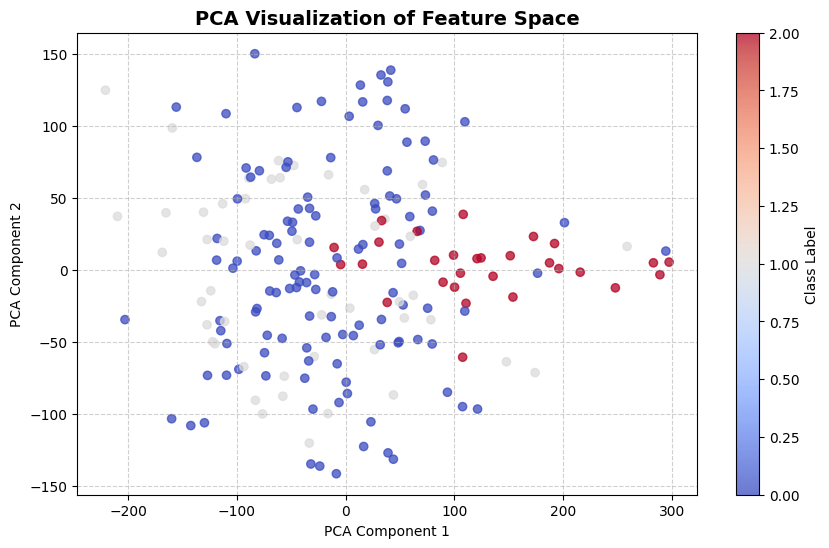

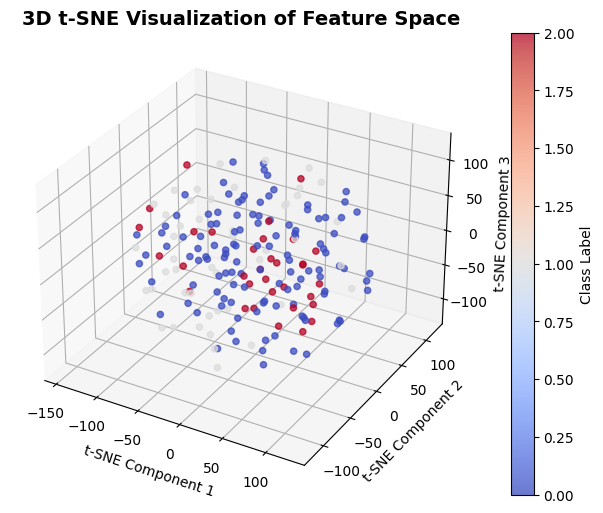

In [21]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ======================== 1. PCA Visualization of Feature Embeddings ========================
def pca_visualization(model, dataset, num_samples=200):
    model.eval()
    features, labels = [], []
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    with torch.no_grad():  # Ensure no gradient calculation
        for i in indices:
            img, label = dataset[i]
            img = img.unsqueeze(0).to("cpu")  # Move to CPU for numpy conversion
            feature = model.features(img).flatten().cpu().numpy()
            features.append(feature)
            labels.append(label)

    features = np.array(features)
    labels = np.array(labels)

    pca = PCA(n_components=2)
    pca_results = pca.fit_transform(features)

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(pca_results[:, 0], pca_results[:, 1], c=labels, cmap="coolwarm", alpha=0.75)
    plt.colorbar(scatter, label="Class Label")
    plt.title("PCA Visualization of Feature Space", fontsize=14, fontweight="bold")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

# Run PCA Visualization
pca_visualization(model, full_dataset)

# ======================== 2. t-SNE 3D Feature Space Visualization ========================
def tsne_3d_visualization(model, dataset, num_samples=200):
    model.eval()
    features, labels = [], []
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    with torch.no_grad():
        for i in indices:
            img, label = dataset[i]
            img = img.unsqueeze(0).to("cpu")  # Move to CPU
            feature = model.features(img).flatten().cpu().numpy()
            features.append(feature)
            labels.append(label)

    features = np.array(features)
    labels = np.array(labels)

    tsne = TSNE(n_components=3, perplexity=30, random_state=42)
    tsne_results = tsne.fit_transform(features)

    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(tsne_results[:, 0], tsne_results[:, 1], tsne_results[:, 2], c=labels, cmap="coolwarm", alpha=0.75)
    fig.colorbar(scatter, label="Class Label")

    ax.set_title("3D t-SNE Visualization of Feature Space", fontsize=14, fontweight="bold")
    ax.set_xlabel("t-SNE Component 1")
    ax.set_ylabel("t-SNE Component 2")
    ax.set_zlabel("t-SNE Component 3")
    plt.show()

# Run 3D t-SNE Visualization
tsne_3d_visualization(model, full_dataset)


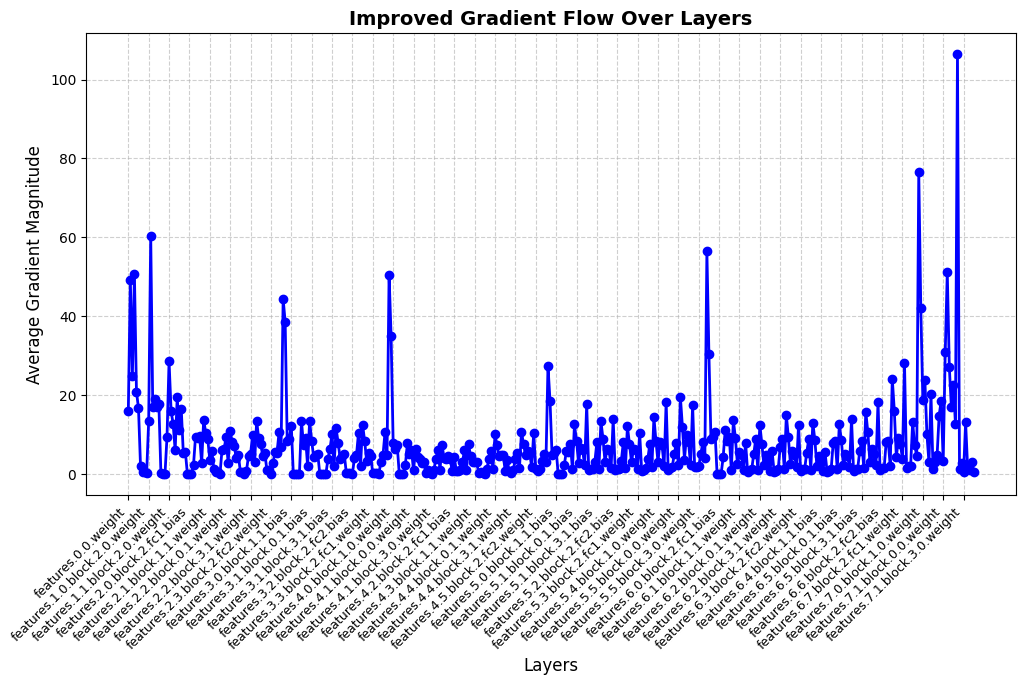

In [28]:
import torch
import matplotlib.pyplot as plt

# Improved function to visualize gradient flow with better label formatting
def improved_plot_gradient_flow(model):
    ave_grads = []
    layers = []

    for name, param in model.named_parameters():
        if param.requires_grad and param.grad is not None:
            layers.append(name)
            ave_grads.append(param.grad.abs().mean().cpu().numpy())

    plt.figure(figsize=(12, 6))
    plt.plot(range(len(layers)), ave_grads, marker="o", linestyle="-", color="b", linewidth=2)
    
    # Format x-axis labels properly
    plt.xticks(range(len(layers))[::10], [layers[i] for i in range(len(layers))[::10]], rotation=45, ha="right", fontsize=9)  # Show every 10th label

    plt.xlabel("Layers", fontsize=12)
    plt.ylabel("Average Gradient Magnitude", fontsize=12)
    plt.title("Improved Gradient Flow Over Layers", fontsize=14, fontweight="bold")
    plt.grid(True, linestyle="--", alpha=0.6)

    plt.show()

# Run the improved gradient flow visualization
improved_plot_gradient_flow(model)
